# PR12 · Choose a spatial scale and inspect boundaries

<!-- paper-first -->
### Begin with the paper question

**Read or revisit [PP01](../../curriculum/papers/processing.md#pp01).** Use the assigned first-pass sections in the guide; if you already read them, return only to the relevant figure or claim. Do this before the technical explanation below.

**Motivation:** How would changing spatial scale affect which structures a downstream result could distinguish?

Write a two-sentence prediction and one thing you cannot yet explain. Ask your AI tutor to locate evidence in the supplied paper and distinguish it from inference. A paper link motivates this question; it does not mean the paper uses every method demonstrated here.

**After the experiment:** revisit your prediction in the [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md). Explain one mechanism you now understand, cite a result from this notebook, and name a paper claim this exercise still cannot test. Keep a small demonstration distinct from a reproduction of the study.
<!-- /paper-first -->

**Format:** 75–100 minutes for this lesson and its small executable lab, followed by the explicitly labeled upstream practice. Run this notebook from a fresh kernel, top to bottom. Core data are synthetic. Software: NumPy, SciPy, Matplotlib; extra imports are stated in code. This is one stage of a longer processing course, not a replacement for supervised research training.

## Learning objectives

- Convert millimeter FWHM to sigma in voxel units.
- Separate requested kernel width from final image smoothness.
- Demonstrate how masks and padding change local averages.

## Understand the operation

Spatial smoothing computes weighted combinations of nearby samples. For a Gaussian, FWHM and standard deviation are different width descriptions: sigma is FWHM divided by approximately2.355. A library may expect FWHM in millimeters or sigma in samples. On anisotropic voxels, the same physical width needs a different sigma along each index axis. Passing the number6 without reading the API can produce a very different transformation.

Smoothing trades spatial specificity against other properties such as noise reduction under a chosen model. It mixes tissue or signals across boundaries and induces local dependence. Previously acquired blur and interpolation contribute to final effective smoothness, so the requested kernel is not the full story. A narrow anatomical structure can be overwhelmed by a kernel that is harmless for a broad pattern. Smoothing parameters therefore belong in the research question and sensitivity analysis, not only in a software default.

Boundary handling changes the estimate. Convolving a masked constant image with zeros outside the mask lowers values near the mask edge. Dividing by the smoothed mask can produce a normalized local average that corrects this particular attenuation, but it changes the effective kernel and does not restore missing anatomy. It should not be described as universally superior. We compare both operators on a constant synthetic disk and separately verify anisotropic sigma conversion. We do not smooth the fourth dimension accidentally: spatial and temporal operations have distinct meanings.

## Transformation contract

**Input:** values, spatial grid, mask and kernel width. **Output:** spatial weighted averages on the same grid. **Preserved:** geometry and constant interior under suitable boundary handling. **Changed:** peaks, spatial dependence, boundary mixtures and effective sampling scale.


## Read the actual course material

- [DartBrains: Preprocessing, Image Transformations and Cost Functions](https://github.com/ljchang/dartbrains/blob/5d727f7a72a7f20bfb32603cac8509d78b9647f2/content/Preprocessing.py). CC BY-SA 4.0; linked pinned course chapter.

Read the named topic alongside this lesson; compare its real-image assumptions with our controlled example. These notebooks use original explanations and original code, not copied upstream passages. The source chapter is the place to continue to a complete real-tool practical. External software and downloaded datasets are not silently run by this notebook.


## Predict, then ask your AI assistant

Use Goose with your installed Ollama model, or ChatGPT. The model is a tutor and code author; the local Python runtime performs these calculations. Paste:

> Convert a6mm FWHM kernel to sigma for2×2×4mm voxels. Explain two distinct boundary operators and show their behavior on the same constant disk. State what each preserves, rather than choosing whichever image looks smoother. Return at most 20 executable lines per cell, show units and array shapes, and preserve the original. Explain the prediction before running. If an assertion fails, diagnose the disagreement rather than deleting the check.

Write your prediction before executing the reference cells below.


In [1]:
import numpy as np
from scipy.ndimage import gaussian_filter,binary_erosion
import matplotlib.pyplot as plt
spacing=np.array([2.,2.,4.]); fwhm=6.
sigma=fwhm/np.sqrt(8*np.log(2))/spacing
assert np.allclose(np.round(sigma,3),[1.274,1.274,.637])
r,c=np.mgrid[:65,:65]; mask=(r-32)**2+(c-32)**2<22**2
image=mask.astype(float)*100
ordinary=gaussian_filter(image,2,mode='constant')
weight=gaussian_filter(mask.astype(float),2,mode='constant')
normalized=np.divide(ordinary,weight,out=np.zeros_like(ordinary),where=weight>1e-8)
boundary=mask & ~binary_erosion(mask,iterations=2)
print('sigma voxels:',sigma,'boundary means:',ordinary[boundary].mean(),normalized[boundary].mean())
assert ordinary[boundary].mean()<90 and np.allclose(normalized[mask],100)


sigma voxels: [1.2739827  1.2739827  0.63699135] boundary means: 65.45152186954985 100.0


Wrong sigma=6 vox gives FWHM mm: [28.25784054 28.25784054 56.51568108]


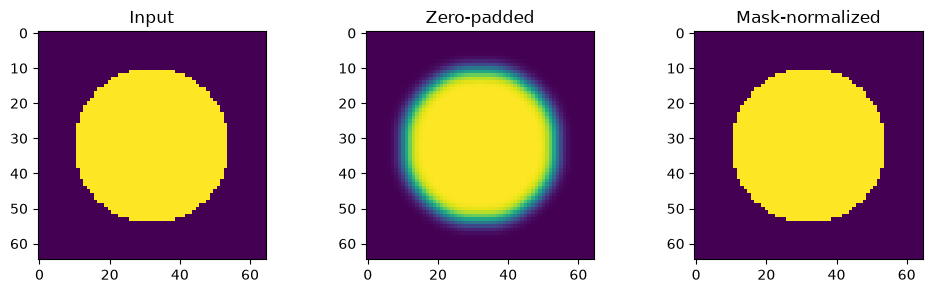

In [2]:
bad_physical_fwhm=6*np.sqrt(8*np.log(2))*spacing
print('Wrong sigma=6 vox gives FWHM mm:',bad_physical_fwhm)
fig,axes=plt.subplots(1,3,figsize=(10,3))
for ax,x,title in zip(axes,[image,ordinary,normalized*mask],['Input','Zero-padded','Mask-normalized']):
    ax.imshow(x,vmin=0,vmax=100,cmap='viridis'); ax.set_title(title)
plt.tight_layout(); plt.show()


## Check and explain

The sigma vector is approximately[1.274,1.274,.637]. Ordinary convolution attenuates the disk boundary while normalized convolution stays100 inside this constructed mask. The wrong-unit vector corresponds to roughly28,28,57mm FWHM.

## Deliberately wrong method

The bad method passes millimeter FWHM directly as voxel sigma. A second mistake would present mask-normalized values outside the mask as newly acquired data. The normalization is a different local estimator, and its altered edge kernel must be acknowledged.

## Transfer to an actual dataset or tool — guided assignment

Use DartBrains Spatial Smoothing and one real anatomical or functional derivative with known voxel sizes. Compare two justified physical widths with identical display limits and cuts. Inspect a small anatomical boundary and record prior resampling/smoothing history. For cortical surfaces, return to the surface notebook: volumetric distance across sulcal banks differs from distance along the sheet. Submit a sensitivity comparison rather than a universal smoothing rule.

**Submit:** a transformation card, one labeled figure or numerical result, the failed-method diagnosis, and the upstream-practice evidence. If the external exercise has not been run, mark it **not executed** and state the missing software/data; do not convert a proposed command into a claimed result.

## Exit questions and answer key

1. Why is scalar voxel sigma anisotropic physically? **Answer:** different voxel spacings convert the same number of samples to different distances.
2. Does edge normalization recover excluded signal? **Answer:** no; it reweights available samples under a changed estimator.


### Return to the research question

Reopen [PP01](../../curriculum/papers/processing.md#pp01) and your initial two-sentence prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure/section locator. State what this small exercise still cannot establish about the published result.
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Reuse this entry in the A2 portfolio when relevant; a separate report is unnecessary.
